In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("../data/fake_job_postings.csv")

In [17]:
df.head(5)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [19]:
# Dataframe info
print("Shape: ", df.shape)
print("\ncolumns\n", df.columns.tolist())

print("\nFake vs Real\n")
print(df['fraudulent'].value_counts())

print("\nMissing values\n")
print(df.isnull().sum())

Shape:  (17880, 18)

columns
 ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Fake vs Real

fraudulent
0    17014
1      866
Name: count, dtype: int64

Missing values

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


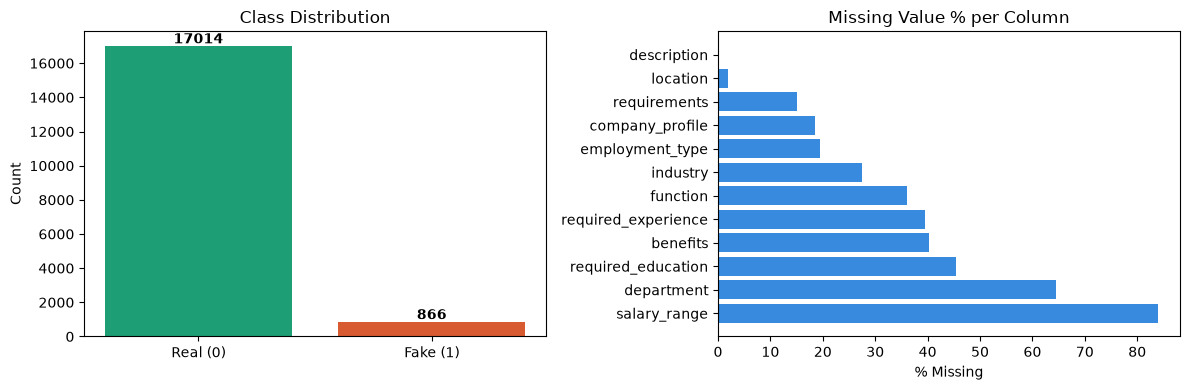

EDA plot saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# class distribution

axes[0].bar(['Real (0)', 'Fake (1)'], df['fraudulent'].value_counts().values, color=['#1D9E75', '#D85A30'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['fraudulent'].value_counts().values):
    axes[0].text(i, v + 150, str(v), ha='center', fontweight='bold')

# Missing value % per column

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct>0]
axes[1].barh(missing_pct.index, missing_pct.values, color = '#378ADD')
axes[1].set_title('Missing Value % per Column')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig('../model/eda_plots.png', dpi=150)
plt.show()
print("EDA plot saved.")

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

# Columns to use

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
meta_cols = ['telecommuting', 'has_company_logog', 'has_questions','employment_type', 
             'required_experience', 'salary_range'] 

# Fill missing text with empty string
df[text_cols] = df[text_cols].fillna('')

# Combine all text columns into one
df['combined_text'] = df[text_cols].apply(lambda row: ' '.join(row.values), axis=1)

# Clean text: lowercase, remove special chars

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['combined_text'] = df['combined_text'].apply(clean_text)

# TF-IDF - top 5000 words
tfidf = TfidfVectorizer(max_features=5000, stop_words = 'english', ngram_range=(1,2) )
X_text = tfidf.fit_transform(df['combined_text'])


print("TF-IDF matrix shape:", X_text.shape)
print("Sample cleaned text:\n", df['combined_text'][0][:300])



TF-IDF matrix shape: (17880, 5000)
Sample cleaned text:
 marketing intern we re food52 and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better w


In [23]:
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp

#Binary flag: is salary missing?

df['salary_missing'] = df['salary_range'].isnull().astype(int)

# Fill missing metadata with 'unknown'

for col in ['employment_type', 'required_experience']:
    df[col] = df[col].fillna('unknown')

# Label encode categorical columns
le_employment = LabelEncoder()
le_experience = LabelEncoder()

df['employment_type_enc'] = le_employment.fit_transform(df['employment_type'])
df['requiremnet_experience_enc'] = le_experience.fit_transform(df['required_experience'])

# Final metadata feature matric

meta_features = df[['telecommuting', 'has_company_logo', 'has_questions', 
                    'employment_type_enc', 'requiremnet_experience_enc', 
                    'salary_missing']].values


print("Metadat feature matrix shape:", meta_features.shape)
print("Sample row:", meta_features[10])
print("\nEmployment type classes:", le_employment.classes_)
print("Experience classes:", df['required_experience'].unique())

Metadat feature matrix shape: (17880, 6)
Sample row: [0 0 0 1 5 0]

Employment type classes: ['Contract' 'Full-time' 'Other' 'Part-time' 'Temporary' 'unknown']
Experience classes: <StringArray>
[      'Internship',   'Not Applicable',          'unknown',
 'Mid-Senior level',        'Associate',      'Entry level',
        'Executive',         'Director']
Length: 8, dtype: str


In [24]:
import scipy.sparse as sp

# convert metadata to sparse matrix and combine with TF-IDF
X_meta = sp.csr_matrix(meta_features)
X_final = sp.hstack([X_text, X_meta])
y = df['fraudulent'].values

print("Final feature matrix shape:", X_final.shape)
print("Target disribution:", y.sum(), "fake /", len(y)-y.sum(), "real")

Final feature matrix shape: (17880, 5006)
Target disribution: 866 fake / 17014 real


In [25]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify = y
)

# scale_pos_weight handles class imbalance
scale = round(17014 / 866)
print("scale_pos_weight:", scale)

model = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    scale_pos_weight = scale,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42  
)

model.fit(X_train, y_train)


scale_pos_weight: 20


d:\fake-job-detector\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:00:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
        Fake       0.81      0.84      0.83       173

    accuracy                           0.98      3576
   macro avg       0.90      0.91      0.91      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC Score: 0.9914


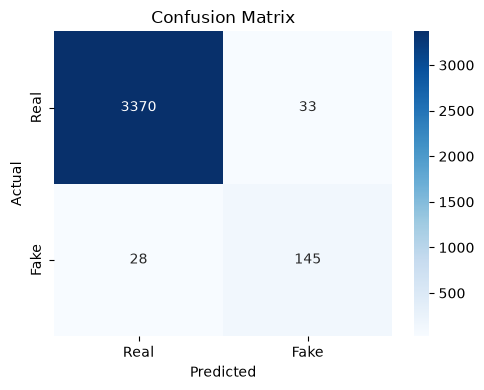

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=150)
plt.show()

d:\fake-job-detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


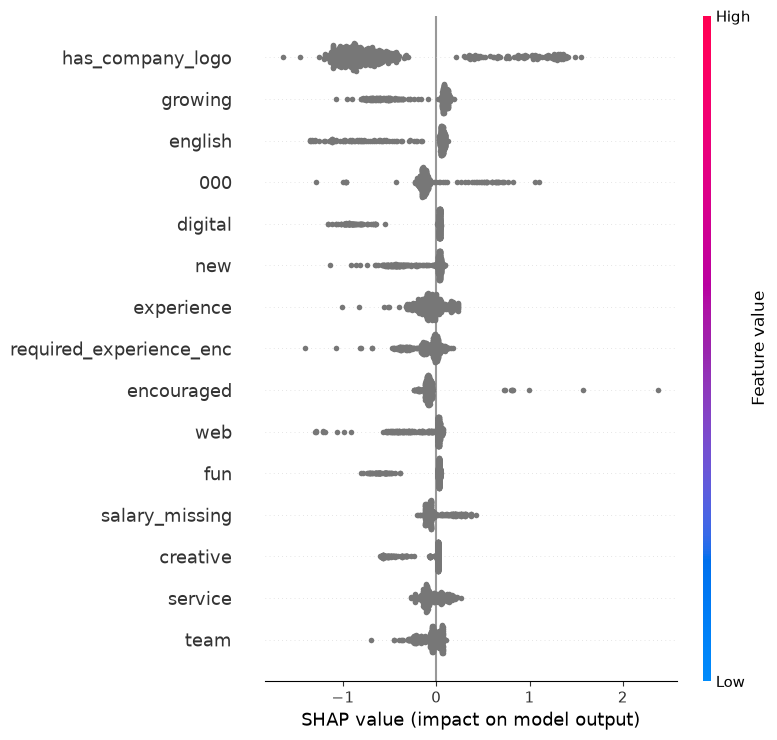

SHAP plot saved.


In [27]:
import shap

# TreeExplainer works directly with XGBoost
explainer = shap.TreeExplainer(model)

# Use a sample of 500 rows (full dataset is slow)
X_sample = X_test[:500]
shap_values = explainer.shap_values(X_sample)

# Get feature names
tfidf_features = tfidf.get_feature_names_out().tolist()
meta_feature_names = ['telecommuting', 'has_company_logo', 'has_questions',
                      'employment_type_enc', 'required_experience_enc', 'salary_missing']

all_features = tfidf_features + meta_feature_names

# Global feature importance plot
shap.summary_plot(shap_values, X_sample, feature_names=all_features, 
                  max_display=15, show=False)
plt.tight_layout()
plt.savefig('../model/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved.")


In [28]:
import joblib
import os

os.makedirs('../model', exist_ok=True)

# Save model
joblib.dump(model, '../model/model.pkl')

# Save TF-IDF vectorizer
joblib.dump(tfidf, '../model/tfidf.pkl')

# Save label encoders
joblib.dump({
    'employment_type': le_employment,
    'required_experience': le_experience
}, '../model/encoders.pkl')

print("Saved:")
print(" ../model/model.pkl")
print(" ../model/tfidf.pkl")
print(" ../model/encoders.pkl")


Saved:
 ../model/model.pkl
 ../model/tfidf.pkl
 ../model/encoders.pkl
